# Hourly Solar + Wind Generation Parser

Part 1: 
- Parses 15-min interval generation-by-fuel data into a clean hourly Solar+Wind renewable generation series.
- Source: `01_data/1.1_raw_bulk/WindSolar Hourly Agg/IntGenbyFuel20**.xlsx`
- time range: 2020 - 2022
- Structure: one sheet per month, rows = (Date, Fuel, Settlement Type), columns = Total + 96 fifteen-min interval readings (MW).
- Aggregation: mean of the four 15-min MW readings per hour, summed across Wind + Solar.

Part 2:
- Parses hourly wind and solar generation data, and aggregate with part 1
- time range: 2023 - 2025
- Structure: onw sheet each for wind and solar data, rows = (datetime), columns = solar/wind generation

In [19]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[1]  # 02_scripts/2_parsers -> repo root
RAW_PATH = PROJECT_ROOT / "01_data/1.1_raw_bulk/WindSolar Hourly Agg" 
    # 2020-2022: IntGenbyFuel20**.xlsx
    # 2023: rpt.00013424.0000000000000000.20240108.110806282.ERCOT_2023_Hourly_WindSolar_Output.xlsx
    # 2024: rpt.00013424.0000000000000000.20250113.111710234.ERCOT_2024_Hourly_WindSolar_Output.xlsx
    # 2025: rpt.00013424.0000000000000000.20260114.150511494.ERCOT_2025_Hourly_WindSolar_Output.xlsx
OUT_PATH = PROJECT_ROOT / "01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)


### 2020 - 2022 Fuel Mix Dataset
`year_20_22`

In [2]:
MONTH_SHEETS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
FUELS = ["Wind", "Solar"]

In [4]:
# Sample check
jan = pd.read_excel(RAW_PATH/'IntGenbyFuel2020.xlsx', sheet_name="Jan")
jan.head(3)

,Date,Fuel,Settlement Type,Total,0:15,0:30,0:45,1:00,1:15,1:30,...,21:45,22:00,22:15,22:30,22:45,23:00,23:15,23:30,23:45,0:00
0,2020-01-01,Biomass,FINAL,829.861577,8.897137,8.857404,8.780167,8.756302,8.982659,8.858266,...,8.452755,8.456484,8.463293,8.472897,8.468771,8.473933,8.480197,8.474832,8.469678,8.478195
1,2020-01-01,Coal,FINAL,153415.741238,1424.554673,1424.204785,1452.406880,1463.547569,1447.432180,1436.953196,...,1659.931048,1636.657217,1634.854318,1762.289305,1795.384043,1717.720251,1674.921768,1651.500306,1630.837442,1636.090874
2,2020-01-01,Gas,FINAL,14934.575434,158.861450,160.416656,160.022975,158.432587,158.819729,158.254566,...,154.243905,153.471064,154.257817,155.080414,153.671443,153.309924,153.757539,153.360790,152.697942,153.754631


In [5]:
# mapping of interval columns to hour
INTERVAL_COLS = jan.columns[4:].to_list()

# 1. hour to list of intervals
dict = {x: INTERVAL_COLS[4*x : 4*(x+1)] for x in range(0, 24)}
# 2. individual intervals to hour
INTERVAL_HOUR = {item: number for number, items_list in dict.items() for item in items_list}
INTERVAL_HOUR

{'0:15': 0,
 '0:30': 0,
 '0:45': 0,
 '1:00': 0,
 '1:15': 1,
 '1:30': 1,
 '1:45': 1,
 '2:00': 1,
 '2:15': 2,
 '2:30': 2,
 '2:45': 2,
 '3:00': 2,
 '3:15': 3,
 '3:30': 3,
 '3:45': 3,
 '4:00': 3,
 '4:15': 4,
 '4:30': 4,
 '4:45': 4,
 '5:00': 4,
 '5:15': 5,
 '5:30': 5,
 '5:45': 5,
 '6:00': 5,
 '6:15': 6,
 '6:30': 6,
 '6:45': 6,
 '7:00': 6,
 '7:15': 7,
 '7:30': 7,
 '7:45': 7,
 '8:00': 7,
 '8:15': 8,
 '8:30': 8,
 '8:45': 8,
 '9:00': 8,
 '9:15': 9,
 '9:30': 9,
 '9:45': 9,
 '10:00': 9,
 '10:15': 10,
 '10:30': 10,
 '10:45': 10,
 '11:00': 10,
 '11:15': 11,
 '11:30': 11,
 '11:45': 11,
 '12:00': 11,
 '12:15': 12,
 '12:30': 12,
 '12:45': 12,
 '13:00': 12,
 '13:15': 13,
 '13:30': 13,
 '13:45': 13,
 '14:00': 13,
 '14:15': 14,
 '14:30': 14,
 '14:45': 14,
 '15:00': 14,
 '15:15': 15,
 '15:30': 15,
 '15:45': 15,
 '16:00': 15,
 '16:15': 16,
 '16:30': 16,
 '16:45': 16,
 '17:00': 16,
 '17:15': 17,
 '17:30': 17,
 '17:45': 17,
 '18:00': 17,
 '18:15': 18,
 '18:30': 18,
 '18:45': 18,
 '19:00': 18,
 '19:15': 19,
 

In [22]:
def parse_sheet(path, sheet: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = df.columns.str.strip()

    df = df[df["Fuel"].isin(FUELS)][["Date", "Fuel"] + INTERVAL_COLS]
    df = df.rename(mapper=INTERVAL_HOUR, axis=1)

    long = df.melt(id_vars=["Date", "Fuel"], var_name="hour", value_name="gen")
    long["datetime"] = long["Date"] + pd.to_timedelta(long["hour"], unit="h")

    hourly = (
        long.groupby(["datetime", "Fuel"])["gen"].sum().round(2)  # sum of 4 x 15-min -> ERCOT use MWh as interval generation
        .groupby("datetime").sum()  # sum Wind + Solar
        .rename("renewable_gen")
        .reset_index()
    )
    return hourly

In [23]:
year_20_22 = pd.DataFrame()
for year in [2020, 2021, 2022]:
    url = RAW_PATH / f'IntGenbyFuel{year}.xlsx'
    year_df = pd.concat([parse_sheet(url, m) for m in MONTH_SHEETS], ignore_index=True)
    year_20_22 = pd.concat([year_20_22, year_df], ignore_index=True)

year_20_22 = year_20_22.sort_values('datetime').reset_index(drop=True)
year_20_22

,datetime,renewable_gen
0,2020-01-01 00:00:00,12832.85
1,2020-01-01 01:00:00,13328.73
2,2020-01-01 02:00:00,13920.06
3,2020-01-01 03:00:00,14443.91
4,2020-01-01 04:00:00,14713.70
...,...,...
26299,2022-12-31 19:00:00,20704.60
26300,2022-12-31 20:00:00,21439.78
26301,2022-12-31 21:00:00,22094.86
26302,2022-12-31 22:00:00,22371.61


In [24]:
# change hour starting to hour ending to match the pattern for rest of ERCOT
year_20_22['datetime'] = year_20_22['datetime'] + pd.Timedelta(hours=1)
year_20_22

,datetime,renewable_gen
0,2020-01-01 01:00:00,12832.85
1,2020-01-01 02:00:00,13328.73
2,2020-01-01 03:00:00,13920.06
3,2020-01-01 04:00:00,14443.91
4,2020-01-01 05:00:00,14713.70
...,...,...
26299,2022-12-31 20:00:00,20704.60
26300,2022-12-31 21:00:00,21439.78
26301,2022-12-31 22:00:00,22094.86
26302,2022-12-31 23:00:00,22371.61


### 2023-2025 Hourly Agg Dataset
`df_23_25`

In [25]:
# RE_SHEETS = ['Wind Data', 'Solar Data']
W_COL = ['Time (Hour-Ending)', 'ERCOT.WIND.GEN']
S_COL = ['Time (Hour-Ending)', 'ERCOT.PVGR.GEN']

In [26]:
def parse_sheet(path) -> pd.DataFrame:
    df_wind = pd.read_excel(path, sheet_name='Wind Data')
    df_wind = df_wind.filter(W_COL)
    df_wind['Time (Hour-Ending)'] = pd.to_datetime(df_wind['Time (Hour-Ending)'])

    df_solar = pd.read_excel(path, sheet_name='Solar Data')
    df_solar = df_solar.filter(S_COL)
    df_solar['Time (Hour-Ending)'] = pd.to_datetime(df_solar['Time (Hour-Ending)'])

    df = pd.merge(df_wind, df_solar, on='Time (Hour-Ending)')

    df['renewable_gen'] = round(df['ERCOT.WIND.GEN'] + df['ERCOT.PVGR.GEN'], 2)
    df = df.drop(columns=['ERCOT.WIND.GEN', 'ERCOT.PVGR.GEN'])
    df = df.rename(columns={'Time (Hour-Ending)' : 'datetime'})

    return df

path2023 = RAW_PATH / 'rpt.00013424.0000000000000000.20240108.110806282.ERCOT_2023_Hourly_WindSolar_Output.xlsx'
parse_sheet(path2023)

,datetime,renewable_gen
0,2023-01-01 01:00:00,21753.73
1,2023-01-01 02:00:00,21570.85
2,2023-01-01 03:00:00,21036.95
3,2023-01-01 04:00:00,20595.94
4,2023-01-01 05:00:00,20388.29
...,...,...
8757,2023-12-31 20:00:00,17161.36
8758,2023-12-31 21:00:00,18301.18
8759,2023-12-31 22:00:00,18607.23
8760,2023-12-31 23:00:00,17865.80


In [27]:
path2023 = RAW_PATH / 'rpt.00013424.0000000000000000.20240108.110806282.ERCOT_2023_Hourly_WindSolar_Output.xlsx'
path2024 = RAW_PATH / 'rpt.00013424.0000000000000000.20250113.111710234.ERCOT_2024_Hourly_WindSolar_Output.xlsx'
path2025 = RAW_PATH / 'rpt.00013424.0000000000000000.20260114.150511494.ERCOT_2025_Hourly_WindSolar_Output.xlsx'
paths = [path2023, path2024, path2025]

df_23_25 = pd.concat([parse_sheet(x) for x in paths], ignore_index=True)
df_23_25

,datetime,renewable_gen
0,2023-01-01 01:00:00,21753.73
1,2023-01-01 02:00:00,21570.85
2,2023-01-01 03:00:00,21036.95
3,2023-01-01 04:00:00,20595.94
4,2023-01-01 05:00:00,20388.29
...,...,...
26305,2025-12-31 20:00:00,9979.51
26306,2025-12-31 21:00:00,13074.09
26307,2025-12-31 22:00:00,15597.96
26308,2025-12-31 23:00:00,17978.92


### merge and export

In [28]:
df_full = pd.concat([year_20_22, df_23_25], ignore_index=True)
df_full = df_full.sort_values('datetime').reset_index(drop=True)

In [29]:
df_full

,datetime,renewable_gen
0,2020-01-01 01:00:00,12832.85
1,2020-01-01 02:00:00,13328.73
2,2020-01-01 03:00:00,13920.06
3,2020-01-01 04:00:00,14443.91
4,2020-01-01 05:00:00,14713.70
...,...,...
52609,2025-12-31 20:00:00,9979.51
52610,2025-12-31 21:00:00,13074.09
52611,2025-12-31 22:00:00,15597.96
52612,2025-12-31 23:00:00,17978.92


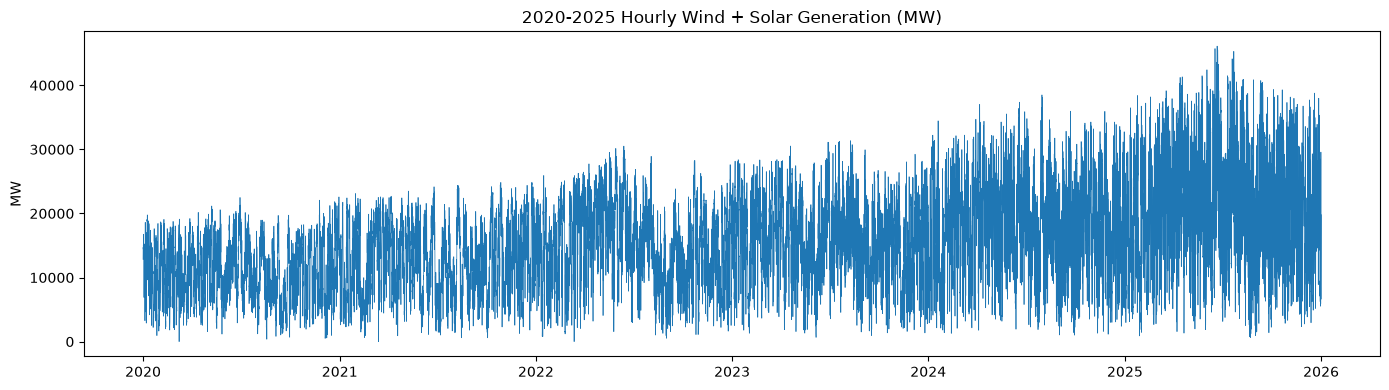

In [30]:
# Plot to eyeball diurnal + seasonal pattern
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_full["datetime"], df_full["renewable_gen"], linewidth=0.5)
ax.set_title("2020-2025 Hourly Wind + Solar Generation (MW)")
ax.set_ylabel("MW")
plt.tight_layout()
plt.show()

In [31]:
df_full.to_parquet(OUT_PATH, index=False)
print("wrote", OUT_PATH, df_full.shape)

wrote /Users/zyliazhang/Git/ERCOT-Research/01_data/2_cleaned/generation/hourly_solar_wind_generation_2020_2025.parquet (52614, 2)
